## *Train-test split, feature engineering and missing value imputation*

### Removal of unnecessary columns

In [1]:
# Important libraries for train-test split and data manipulation

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Iterative imputer for handling missing values
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import mean_squared_error


In [33]:
# Load the cleaned data
data_path = '../data/cleaned/knee-provider-cleaned.parquet'
df = pd.read_parquet(data_path)

print(f"Dataset shape: {df.shape}")
print(f"\nNumber of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")

Dataset shape: (132382, 81)

Number of rows: 132,382
Number of columns: 81


In [34]:
df.columns.to_list()

['provider_code',
 'procedure',
 'revision_flag',
 'year',
 'age_band',
 'gender',
 't0_assisted',
 't0_assisted_by',
 't0_symptom_period',
 't0_previous_surgery',
 't0_living_arrangements',
 't0_disability',
 'heart_disease',
 'high_bp',
 'stroke',
 'circulation',
 'lung_disease',
 'diabetes',
 'kidney_disease',
 'nervous_system',
 'liver_disease',
 'cancer',
 'depression',
 'arthritis',
 't0_mobility',
 't0_self_care',
 't0_activity',
 't0_discomfort',
 't0_anxiety',
 't0_eq5d_index_profile',
 't0_eq5d_index',
 't1_assisted',
 't1_assisted_by',
 't1_living_arrangements',
 't1_disability',
 't1_mobility',
 't1_self_care',
 't1_activity',
 't1_discomfort',
 't1_anxiety',
 't1_satisfaction',
 't1_sucess',
 't1_allergy',
 't1_bleeding',
 't1_wound',
 't1_urine',
 't1_further_surgery',
 't1_readmitted',
 't1_eq5d_index_profile',
 't1_eq5d_index',
 'oks_eq_5d_index_t1_predicted',
 't0_eq_vas',
 't1_eq_vas',
 'oks_eq_vas_t1_predicted',
 'oks_t0_pain',
 'oks_t0_night_pain',
 'oks_t0_washing'

In [35]:
# Final dataset clean-up
# Remove the following columns: all values that contains t1, except oks_t1_score

columns_to_drop = [col for col in df.columns if 't1' in col and col != 'oks_t1_score']

df.drop(columns=columns_to_drop, inplace=True)
df.columns.to_list()

# Remove the following columns

columns_to_drop_2 = ['procedure', 'revision_flag', 't0_eq5d_index_profile',  't0_eq5d_index', 't0_eq_vas']
df.drop(columns=columns_to_drop_2, inplace=True)
df.columns.to_list()


['provider_code',
 'year',
 'age_band',
 'gender',
 't0_assisted',
 't0_assisted_by',
 't0_symptom_period',
 't0_previous_surgery',
 't0_living_arrangements',
 't0_disability',
 'heart_disease',
 'high_bp',
 'stroke',
 'circulation',
 'lung_disease',
 'diabetes',
 'kidney_disease',
 'nervous_system',
 'liver_disease',
 'cancer',
 'depression',
 'arthritis',
 't0_mobility',
 't0_self_care',
 't0_activity',
 't0_discomfort',
 't0_anxiety',
 'oks_t0_pain',
 'oks_t0_night_pain',
 'oks_t0_washing',
 'oks_t0_transport',
 'oks_t0_walking',
 'oks_t0_standing',
 'oks_t0_limping',
 'oks_t0_kneeling',
 'oks_t0_work',
 'oks_t0_confidence',
 'oks_t0_shopping',
 'oks_t0_stairs',
 'oks_t0_score',
 'oks_t1_score']

In [36]:
# Create oks_delta_column and oks_target_variable based on 7 points as threshold in oks_delta
df['oks_delta'] = df['oks_t1_score'] - df['oks_t0_score']
df['oks_target_variable'] = np.where(df['oks_delta'] > 7, 0, 1)


df.columns.to_list()
df.head(5)

,provider_code,year,age_band,gender,t0_assisted,t0_assisted_by,t0_symptom_period,t0_previous_surgery,t0_living_arrangements,t0_disability,...,oks_t0_limping,oks_t0_kneeling,oks_t0_work,oks_t0_confidence,oks_t0_shopping,oks_t0_stairs,oks_t0_score,oks_t1_score,oks_delta,oks_target_variable
0,ADP02,2018/19,NaN,NaN,2,0,2,2,2,1,...,0,1,1,2,2,2,17.0,40.0,23.0,0
1,ADP02,2018/19,NaN,NaN,2,0,2,2,2,2,...,1,4,4,3,4,4,37.0,44.0,7.0,1
2,ADP02,2018/19,NaN,NaN,2,0,2,2,1,2,...,2,3,3,3,3,4,37.0,46.0,9.0,0
3,ADP02,2018/19,NaN,NaN,2,0,2,2,2,1,...,2,0,1,3,3,2,22.0,36.0,14.0,0
4,ADP02,2018/19,NaN,NaN,1,0,3,2,2,1,...,0,1,1,0,0,0,12.0,28.0,16.0,0


In [37]:
# Remove oks_t1_score

df.drop(columns=['oks_t1_score'], inplace=True)

In [39]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Column groups
null_columns = ['age_band', 'gender']
sentinel_columns = [
    't0_disability', 't0_discomfort', 't0_anxiety', 
    't0_activity', 't0_self_care', 't0_mobility', 
    't0_living_arrangements', 't0_assisted', 
    't0_symptom_period', 't0_previous_surgery'
]
all_impute_columns = null_columns + sentinel_columns

print("=== STEP 1: Replace Sentinel Values (9 → NaN) ===\n")

# Create clean copy
df_clean = df.copy()

# Replace 9 with NaN
for col in sentinel_columns:
    if col in df_clean.columns:
        count_9s = (df_clean[col] == 9).sum()
        df_clean[col] = df_clean[col].replace(9, np.nan)
        print(f"✓ {col}: Replaced {count_9s:,} nines with NaN")

print(f"\n✓ Sentinel values replaced")

=== STEP 1: Replace Sentinel Values (9 → NaN) ===

✓ t0_disability: Replaced 5,554 nines with NaN
✓ t0_discomfort: Replaced 5,227 nines with NaN
✓ t0_anxiety: Replaced 4,863 nines with NaN
✓ t0_activity: Replaced 4,248 nines with NaN
✓ t0_self_care: Replaced 4,171 nines with NaN
✓ t0_mobility: Replaced 4,052 nines with NaN
✓ t0_living_arrangements: Replaced 1,905 nines with NaN
✓ t0_assisted: Replaced 1,402 nines with NaN
✓ t0_symptom_period: Replaced 1,040 nines with NaN
✓ t0_previous_surgery: Replaced 915 nines with NaN

✓ Sentinel values replaced


In [40]:
# Summarize percentages of NaN

nan_summary = pd.DataFrame({
    'Column': all_impute_columns,
    'NaN Count': [df_clean[col].isna().sum() for col in all_impute_columns],
    'NaN Percentage': [df_clean[col].isna().mean() * 100 for col in all_impute_columns]
})

print("\n=== STEP 2: NaN Summary ===\n")
print(nan_summary)


=== STEP 2: NaN Summary ===

                    Column  NaN Count  NaN Percentage
0                 age_band       9028        6.819658
1                   gender       9028        6.819658
2            t0_disability       5554        4.195434
3            t0_discomfort       5227        3.948422
4               t0_anxiety       4863        3.673460
5              t0_activity       4248        3.208895
6             t0_self_care       4171        3.150730
7              t0_mobility       4052        3.060839
8   t0_living_arrangements       1905        1.439017
9              t0_assisted       1402        1.059056
10       t0_symptom_period       1040        0.785605
11     t0_previous_surgery        915        0.691182


In [41]:
# Overwrite df and saved

data_path_final = '../data/cleaned/knee-provider-target.parquet'
df_clean.to_parquet(data_path_final, index=False)
print(f"Final dataset shape: {df_clean.shape}")

Final dataset shape: (132382, 42)


### Missing Value analysis 

In [42]:
df = df_clean.copy()  # Overwrite df for further processing

In [43]:
# Investigate why age_band and gender have same missing values
# Replace 'df' with your actual dataframe

import pandas as pd
import numpy as np

# Create binary indicators for missing values
df_missing = pd.DataFrame({
    'age_band_missing': df['age_band'].isna(),
    'gender_missing': df['gender'].isna()
})

# Add other columns that might explain the pattern
categorical_cols = ['provider_code', 'year', 't0_assisted_by']
for col in categorical_cols:
    if col in df.columns:
        df_missing[col] = df[col]

print("=== STEP 1: Are age_band and gender missing in EXACTLY the same rows? ===")
same_rows = (df_missing['age_band_missing'] == df_missing['gender_missing']).all()
print(f"Answer: {same_rows}")
print(f"Rows with both missing: {(df_missing['age_band_missing'] & df_missing['gender_missing']).sum()}")
print(f"Rows with only age_band missing: {(df_missing['age_band_missing'] & ~df_missing['gender_missing']).sum()}")
print(f"Rows with only gender missing: {(~df_missing['age_band_missing'] & df_missing['gender_missing']).sum()}")
print()

print("=== STEP 2: What other variables are missing when age_band/gender are missing? ===")
# Look at rows where age_band is missing
missing_age_rows = df_missing[df_missing['age_band_missing']]
print("\nWhen age_band is missing, % of other variables also missing:")
for col in df_missing.columns:
    if col.endswith('_missing') and col not in ['age_band_missing', 'gender_missing']:
        pct = missing_age_rows[col].mean() * 100
        print(f"  {col.replace('_missing', '')}: {pct:.1f}%")
print()

print("=== STEP 3: Correlation between missingness patterns ===")
missing_cols = [col for col in df_missing.columns if col.endswith('_missing')]
correlation_matrix = df_missing[missing_cols].astype(int).corr()
print("\nCorrelation of missingness (1.0 = always missing together):")
print(correlation_matrix[['age_band_missing', 'gender_missing']])
print()

print("=== STEP 4: Does missingness relate to specific categories? ===")
for col in categorical_cols:
    if col in df_missing.columns:
        print(f"\nMissing age_band/gender by {col}:")
        grouped = df_missing.groupby(col)['age_band_missing'].agg(['sum', 'count'])
        grouped['missing_pct'] = (grouped['sum'] / grouped['count'] * 100).round(1)
        grouped = grouped.sort_values('missing_pct', ascending=False)
        print(grouped.head(10))
        print()

print("=== STEP 5: Look at actual rows where age_band/gender are missing ===")
missing_rows = df[df['age_band'].isna()]
print(f"\nTotal rows with missing age_band/gender: {len(missing_rows)}")
print("\nSample of these rows (all columns):")
print(missing_rows.head(10))
print()

print("=== STEP 6: Distribution of values in NON-missing vs MISSING groups ===")
# Compare characteristics of rows with vs without missing age_band
print("\nNon-missing group characteristics:")
non_missing = df[df['age_band'].notna()]
for col in categorical_cols:
    if col in df.columns:
        print(f"\n{col} distribution (non-missing):")
        print(non_missing[col].value_counts(normalize=True).head())

print("\n" + "="*60)
print("Missing group characteristics:")
for col in categorical_cols:
    if col in df.columns:
        print(f"\n{col} distribution (missing):")
        print(missing_rows[col].value_counts(normalize=True).head())

=== STEP 1: Are age_band and gender missing in EXACTLY the same rows? ===
Answer: True
Rows with both missing: 9028
Rows with only age_band missing: 0
Rows with only gender missing: 0

=== STEP 2: What other variables are missing when age_band/gender are missing? ===

When age_band is missing, % of other variables also missing:

=== STEP 3: Correlation between missingness patterns ===

Correlation of missingness (1.0 = always missing together):
                  age_band_missing  gender_missing
age_band_missing               1.0             1.0
gender_missing                 1.0             1.0

=== STEP 4: Does missingness relate to specific categories? ===

Missing age_band/gender by provider_code:
               sum  count  missing_pct
provider_code                         
NT343           10     10        100.0
NT345           38     38        100.0
NT310           11     11        100.0
NT30A           12     12        100.0
NT315           21     21        100.0
NT308           2

C:\Users\asaras\AppData\Local\Temp\ipykernel_25032\664137291.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_missing.groupby(col)['age_band_missing'].agg(['sum', 'count'])
C:\Users\asaras\AppData\Local\Temp\ipykernel_25032\664137291.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_missing.groupby(col)['age_band_missing'].agg(['sum', 'count'])


C:\Users\asaras\AppData\Local\Temp\ipykernel_25032\1193885103.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  year_missing = df_missing.groupby('year')['age_band_missing'].agg(['sum', 'count'])
C:\Users\asaras\AppData\Local\Temp\ipykernel_25032\1193885103.py:93: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  provider_missing = df_missing.groupby('provider_code')['age_band_missing'].agg(['sum', 'count'])


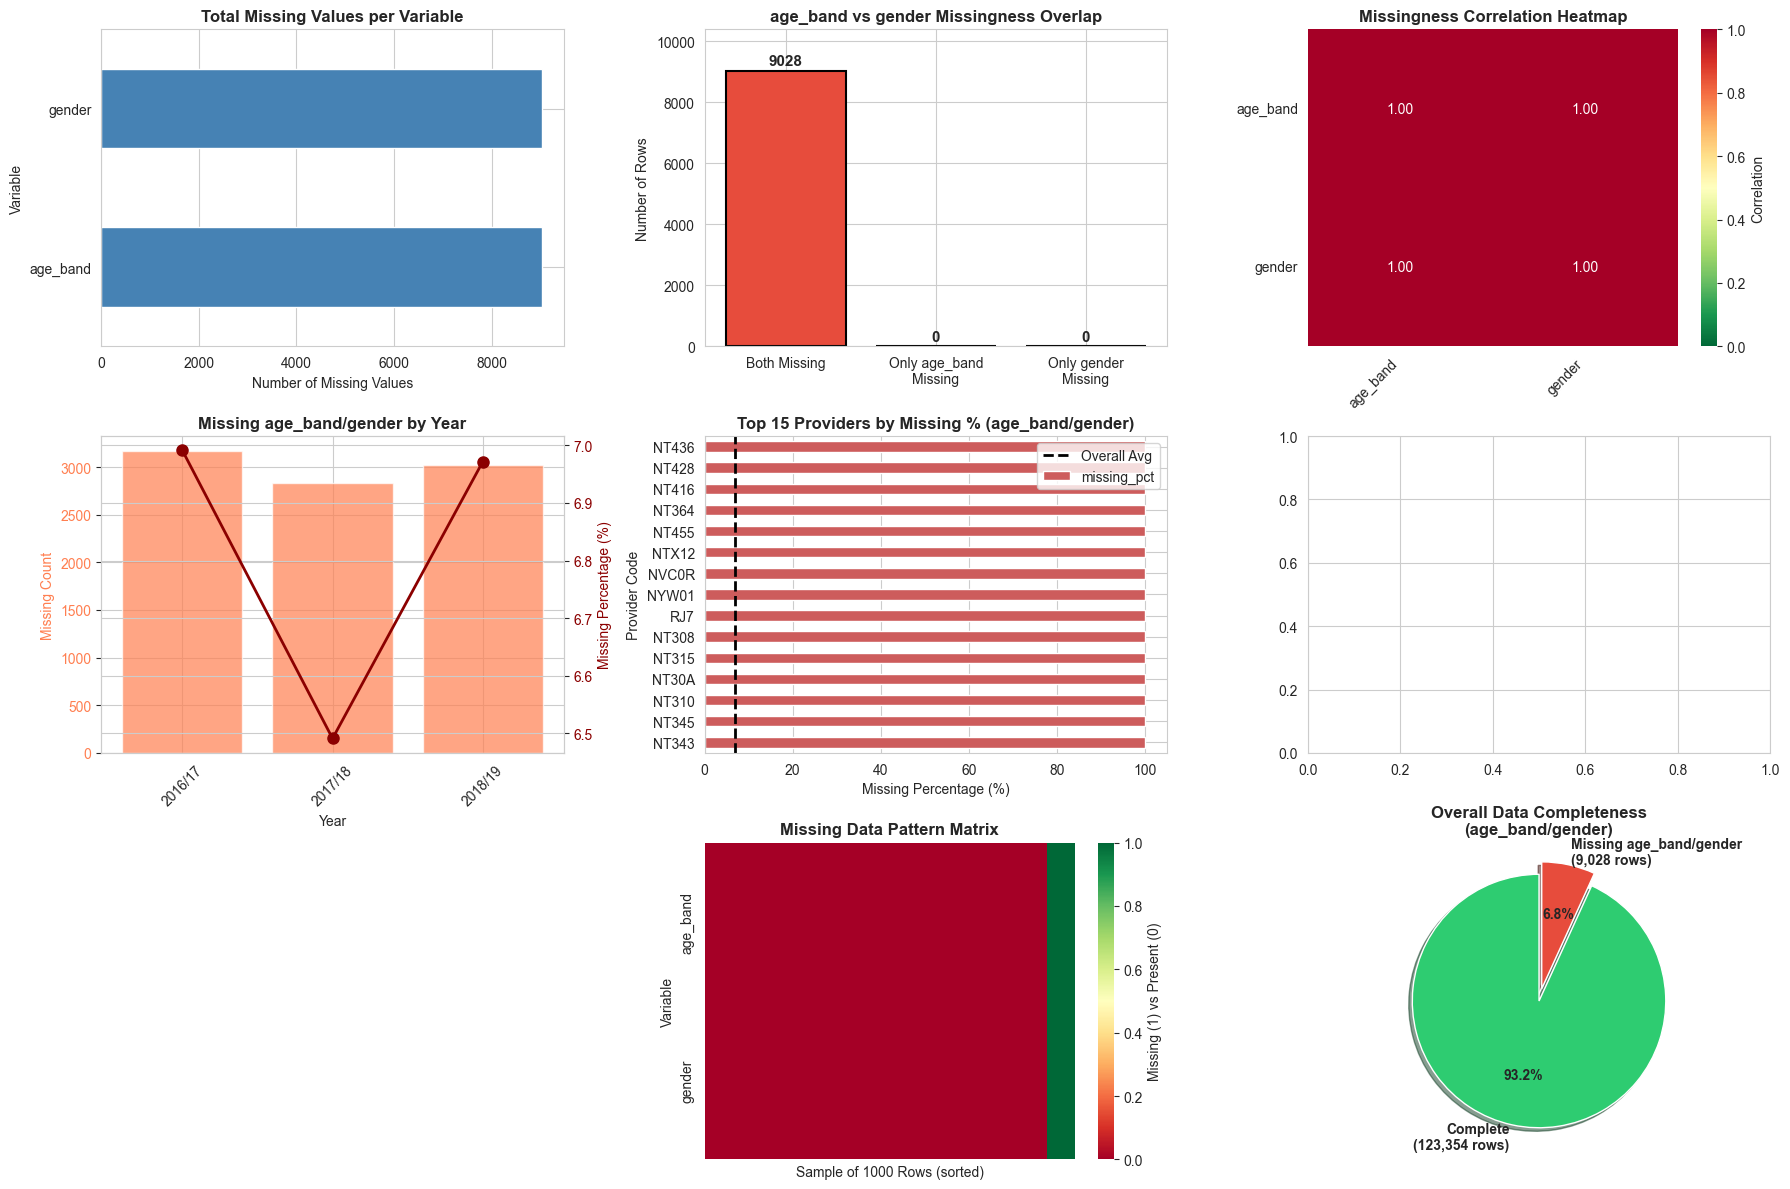


KEY INSIGHTS
✓ age_band and gender missing in same rows: True
✓ Total missing: 9,028 rows (6.8%)
✓ Rows with ONLY age_band missing: 0
✓ Rows with ONLY gender missing: 0


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# Create binary indicators for missing values
missing_cols_to_check = [
    'age_band', 'gender'
]

df_missing = pd.DataFrame({
    f'{col}_missing': df[col].isna() 
    for col in missing_cols_to_check if col in df.columns
})

# Add categorical columns
categorical_cols = ['provider_code', 'year', 't0_disability', 't0_discomfort', 
    't0_anxiety', 't0_activity', 't0_self_care', 't0_mobility', 
    't0_living_arrangements', 't0_assisted']
for col in categorical_cols:
    if col in df.columns:
        df_missing[col] = df[col]

# Create figure with subplots
fig = plt.figure(figsize=(18, 12))

# ============ PLOT 1: Missing data overview ============
ax1 = plt.subplot(3, 3, 1)
missing_counts = df_missing[[col for col in df_missing.columns if col.endswith('_missing')]].sum()
missing_counts = missing_counts.sort_values(ascending=True)
missing_counts.plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_xlabel('Number of Missing Values')
ax1.set_ylabel('Variable')
ax1.set_title('Total Missing Values per Variable', fontsize=12, fontweight='bold')
ax1.set_yticklabels([label.get_text().replace('_missing', '') for label in ax1.get_yticklabels()])

# ============ PLOT 2: Venn diagram-style overlap ============
ax2 = plt.subplot(3, 3, 2)
age_only = (df['age_band'].isna() & df['gender'].notna()).sum()
gender_only = (df['gender'].isna() & df['age_band'].notna()).sum()
both = (df['age_band'].isna() & df['gender'].isna()).sum()
neither = (~df['age_band'].isna() & ~df['gender'].notna()).sum()

categories = ['Both Missing', 'Only age_band\nMissing', 'Only gender\nMissing']
values = [both, age_only, gender_only]
colors = ['#e74c3c', '#3498db', '#2ecc71']
ax2.bar(categories, values, color=colors, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Number of Rows')
ax2.set_title('age_band vs gender Missingness Overlap', fontsize=12, fontweight='bold')
for i, v in enumerate(values):
    ax2.text(i, v + max(values)*0.02, str(v), ha='center', fontweight='bold', fontsize=11)
ax2.set_ylim(0, max(values) * 1.15)

# ============ PLOT 3: Correlation heatmap of missingness ============
ax3 = plt.subplot(3, 3, 3)
missing_only = df_missing[[col for col in df_missing.columns if col.endswith('_missing')]]
corr_matrix = missing_only.astype(int).corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn_r', center=0.5, 
            ax=ax3, cbar_kws={'label': 'Correlation'}, vmin=0, vmax=1)
ax3.set_title('Missingness Correlation Heatmap', fontsize=12, fontweight='bold')
ax3.set_xticklabels([label.get_text().replace('_missing', '') for label in ax3.get_xticklabels()], rotation=45, ha='right')
ax3.set_yticklabels([label.get_text().replace('_missing', '') for label in ax3.get_yticklabels()], rotation=0)

# ============ PLOT 4: Missing by Year ============
if 'year' in df_missing.columns:
    ax4 = plt.subplot(3, 3, 4)
    year_missing = df_missing.groupby('year')['age_band_missing'].agg(['sum', 'count'])
    year_missing['missing_pct'] = (year_missing['sum'] / year_missing['count'] * 100)
    year_missing = year_missing.sort_index()
    
    ax4_twin = ax4.twinx()
    x_pos = range(len(year_missing))
    bars = ax4.bar(x_pos, year_missing['sum'], alpha=0.7, color='coral', label='Missing Count')
    line = ax4_twin.plot(x_pos, year_missing['missing_pct'], color='darkred', marker='o', 
                         linewidth=2, markersize=8, label='Missing %')
    
    ax4.set_xlabel('Year')
    ax4.set_ylabel('Missing Count', color='coral')
    ax4_twin.set_ylabel('Missing Percentage (%)', color='darkred')
    ax4.set_title('Missing age_band/gender by Year', fontsize=12, fontweight='bold')
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels(year_missing.index, rotation=45)
    ax4.tick_params(axis='y', labelcolor='coral')
    ax4_twin.tick_params(axis='y', labelcolor='darkred')

# ============ PLOT 5: Missing by Provider (top 15) ============
if 'provider_code' in df_missing.columns:
    ax5 = plt.subplot(3, 3, 5)
    provider_missing = df_missing.groupby('provider_code')['age_band_missing'].agg(['sum', 'count'])
    provider_missing['missing_pct'] = (provider_missing['sum'] / provider_missing['count'] * 100)
    provider_missing = provider_missing.sort_values('missing_pct', ascending=False).head(15)
    
    provider_missing['missing_pct'].plot(kind='barh', ax=ax5, color='indianred')
    ax5.set_xlabel('Missing Percentage (%)')
    ax5.set_ylabel('Provider Code')
    ax5.set_title('Top 15 Providers by Missing % (age_band/gender)', fontsize=12, fontweight='bold')
    ax5.axvline(x=df_missing['age_band_missing'].mean()*100, color='black', 
                linestyle='--', linewidth=2, label='Overall Avg')
    ax5.legend()

# ============ PLOT 6: Co-occurrence pattern ============
ax6 = plt.subplot(3, 3, 6)
# Show how often other variables are missing when age_band is missing
missing_when_age_missing = df_missing[df_missing['age_band_missing']]
other_missing_pct = {}
for col in df_missing.columns:
    if col.endswith('_missing') and col not in ['age_band_missing', 'gender_missing']:
        other_missing_pct[col.replace('_missing', '')] = missing_when_age_missing[col].mean() * 100

if other_missing_pct:
    sorted_pct = dict(sorted(other_missing_pct.items(), key=lambda x: x[1], reverse=True))
    ax6.barh(list(sorted_pct.keys()), list(sorted_pct.values()), color='mediumpurple')
    ax6.set_xlabel('% Also Missing')
    ax6.set_ylabel('Variable')
    ax6.set_title('When age_band is Missing,\n% of Other Variables Also Missing', fontsize=12, fontweight='bold')
    ax6.axvline(x=50, color='red', linestyle='--', linewidth=1, alpha=0.5)
    ax6.set_xlim(0, 105)

# ============ PLOT 7: Missing by procedure type ============
if 'procedure' in df_missing.columns:
    ax7 = plt.subplot(3, 3, 7)
    proc_missing = df_missing.groupby('procedure')['age_band_missing'].agg(['sum', 'count'])
    proc_missing['missing_pct'] = (proc_missing['sum'] / proc_missing['count'] * 100)
    
    proc_missing['missing_pct'].plot(kind='bar', ax=ax7, color='teal')
    ax7.set_xlabel('Procedure Type')
    ax7.set_ylabel('Missing Percentage (%)')
    ax7.set_title('Missing age_band/gender by Procedure', fontsize=12, fontweight='bold')
    ax7.set_xticklabels(ax7.get_xticklabels(), rotation=45, ha='right')

# ============ PLOT 8: Missing data matrix visualization ============
ax8 = plt.subplot(3, 3, 8)
# Sample 1000 rows to visualize pattern
sample_size = min(1000, len(df_missing))
sample_idx = np.random.choice(df_missing.index, sample_size, replace=False)
missing_matrix = df_missing.loc[sample_idx, [col for col in df_missing.columns if col.endswith('_missing')]].astype(int)
missing_matrix = missing_matrix.sort_values(by=list(missing_matrix.columns))

sns.heatmap(missing_matrix.T, cmap='RdYlGn', cbar_kws={'label': 'Missing (1) vs Present (0)'}, 
            ax=ax8, yticklabels=[col.replace('_missing', '') for col in missing_matrix.columns],
            xticklabels=False)
ax8.set_xlabel(f'Sample of {sample_size} Rows (sorted)')
ax8.set_ylabel('Variable')
ax8.set_title('Missing Data Pattern Matrix', fontsize=12, fontweight='bold')

# ============ PLOT 9: Pie chart of overall missingness ============
ax9 = plt.subplot(3, 3, 9)
total_rows = len(df)
missing_age_gender = df['age_band'].isna().sum()
complete_rows = total_rows - missing_age_gender

sizes = [complete_rows, missing_age_gender]
labels = [f'Complete\n({complete_rows:,} rows)', f'Missing age_band/gender\n({missing_age_gender:,} rows)']
colors = ['#2ecc71', '#e74c3c']
explode = (0, 0.1)

ax9.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=90, textprops={'fontsize': 10, 'fontweight': 'bold'})
ax9.set_title('Overall Data Completeness\n(age_band/gender)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Print key insights
print("\n" + "="*70)
print("KEY INSIGHTS")
print("="*70)
print(f"✓ age_band and gender missing in same rows: {(df['age_band'].isna() == df['gender'].isna()).all()}")
print(f"✓ Total missing: {df['age_band'].isna().sum():,} rows ({df['age_band'].isna().mean()*100:.1f}%)")
print(f"✓ Rows with ONLY age_band missing: {(df['age_band'].isna() & df['gender'].notna()).sum()}")
print(f"✓ Rows with ONLY gender missing: {(df['gender'].isna() & df['age_band'].notna()).sum()}")
print("="*70)


### Train-test split and missing value imputation

In [45]:
# Train-test split

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from collections import Counter

# Assuming you're predicting something like revision_flag or a binary outcome
# Prepare your features and target
X = df.drop(['oks_target_variable', 'oks_delta'], axis=1)  # Replace with your target
y = df['oks_target_variable']

# Check class distribution
print("Original class distribution:")
print(Counter(y))
print(f"Imbalance ratio: {Counter(y)[0]/Counter(y)[1]:.2f}:1")

Original class distribution:
Counter({0: 108510, 1: 23872})
Imbalance ratio: 4.55:1


In [46]:
X.head(50)

,provider_code,year,age_band,gender,t0_assisted,t0_assisted_by,t0_symptom_period,t0_previous_surgery,t0_living_arrangements,t0_disability,...,oks_t0_transport,oks_t0_walking,oks_t0_standing,oks_t0_limping,oks_t0_kneeling,oks_t0_work,oks_t0_confidence,oks_t0_shopping,oks_t0_stairs,oks_t0_score
0,ADP02,2018/19,NaN,NaN,2.0,0,2.0,2.0,2.0,1.0,...,2,2,2,0,1,1,2,2,2,17.0
1,ADP02,2018/19,NaN,NaN,2.0,0,2.0,2.0,2.0,2.0,...,4,0,4,1,4,4,3,4,4,37.0
2,ADP02,2018/19,NaN,NaN,2.0,0,2.0,2.0,1.0,2.0,...,4,2,4,2,3,3,3,3,4,37.0
3,ADP02,2018/19,NaN,NaN,2.0,0,2.0,2.0,2.0,1.0,...,2,2,2,2,0,1,3,3,2,22.0
4,ADP02,2018/19,NaN,NaN,1.0,0,3.0,2.0,2.0,1.0,...,2,2,1,0,1,1,0,0,0,12.0
5,ADP02,2018/19,NaN,NaN,1.0,0,4.0,2.0,1.0,2.0,...,4,3,2,3,1,2,4,2,3,29.0
6,ADP02,2018/19,NaN,NaN,2.0,0,3.0,2.0,1.0,2.0,...,3,4,2,3,2,3,3,3,2,32.0
7,ADP02,2018/19,NaN,NaN,2.0,0,2.0,2.0,1.0,1.0,...,1,2,1,1,0,0,0,1,1,10.0
8,ADP02,2018/19,NaN,NaN,2.0,0,3.0,2.0,2.0,1.0,...,2,2,1,2,1,2,1,0,1,16.0
9,ADP02,2018/19,NaN,NaN,1.0,0,2.0,2.0,1.0,2.0,...,4,2,3,3,0,2,2,3,3,29.0


In [47]:
# convert age_band to categorical, 1,2,3,4,5 for Unique values in age_band (train): ['70 to 79', '80 to 89', '60 to 69','50 to 59', '90 to 120', '40 to 49']

age_band_mapping = {
    '40 to 49': 1,
    '50 to 59': 2,
    '60 to 69': 3,
    '70 to 79': 4,
    '80 to 89': 5,
    '90 to 120': 6
}
X['age_band'] = X['age_band'].map(age_band_mapping)
X['age_band'] = X['age_band'].astype('category')

In [48]:
X.head(100)

,provider_code,year,age_band,gender,t0_assisted,t0_assisted_by,t0_symptom_period,t0_previous_surgery,t0_living_arrangements,t0_disability,...,oks_t0_transport,oks_t0_walking,oks_t0_standing,oks_t0_limping,oks_t0_kneeling,oks_t0_work,oks_t0_confidence,oks_t0_shopping,oks_t0_stairs,oks_t0_score
0,ADP02,2018/19,NaN,NaN,2.0,0,2.0,2.0,2.0,1.0,...,2,2,2,0,1,1,2,2,2,17.0
1,ADP02,2018/19,NaN,NaN,2.0,0,2.0,2.0,2.0,2.0,...,4,0,4,1,4,4,3,4,4,37.0
2,ADP02,2018/19,NaN,NaN,2.0,0,2.0,2.0,1.0,2.0,...,4,2,4,2,3,3,3,3,4,37.0
3,ADP02,2018/19,NaN,NaN,2.0,0,2.0,2.0,2.0,1.0,...,2,2,2,2,0,1,3,3,2,22.0
4,ADP02,2018/19,NaN,NaN,1.0,0,3.0,2.0,2.0,1.0,...,2,2,1,0,1,1,0,0,0,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,NT202,2018/19,NaN,NaN,2.0,0,4.0,2.0,1.0,1.0,...,2,2,2,2,1,2,0,4,3,22.0
97,NT202,2018/19,NaN,NaN,2.0,0,2.0,2.0,2.0,1.0,...,3,1,1,0,1,2,1,2,2,19.0
98,NT202,2018/19,NaN,NaN,2.0,0,2.0,2.0,1.0,2.0,...,2,3,1,0,0,1,3,3,2,18.0
99,NT202,2018/19,NaN,NaN,2.0,0,2.0,2.0,1.0,2.0,...,2,2,2,1,2,0,0,2,2,17.0


In [49]:
# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Keep class distribution
)

print(f"Training set: {len(X_train):,} rows")
print(f"Test set: {len(X_test):,} rows")
print(f"\nTarget distribution:")
print(f"  Train: {y_train.value_counts().to_dict()}")
print(f"  Test: {y_test.value_counts().to_dict()}")


Training set: 105,905 rows
Test set: 26,477 rows

Target distribution:
  Train: {0: 86808, 1: 19097}
  Test: {0: 21702, 1: 4775}


In [50]:
# Binary variables

binary_columns = [
    'gender', 't0_assisted', 't0_previous_surgery', 't0_disability'
]

binary_health_columns = [
    'heart_disease', 'high_bp', 'stroke', 'circulation', 'lung_disease', 'diabetes', 'kidney_disease', 
    'nervous_system', 'liver_disease', 'cancer', 'depression', 'arthritis'
]

categorical_columns = [
    'provider_code', 'year', 'age_band', 't0_assisted_by',
    't0_living_arrangements'
]

for col in binary_columns:
    X_train[col] = X_train[col].map({1: 1, 2: 0})
    X_test[col] = X_test[col].map({1: 1, 2: 0})

for col in binary_health_columns:
    X_train[col] = X_train[col].map({1: 1, 9: 0})
    X_test[col] = X_test[col].map({1: 1, 9: 0})

In [53]:
# Check the categories and their frequencies
print("age_band categories:")
print(X_train['age_band'].value_counts(dropna=False))
print("\nage_band category dtype:", X_train['age_band'].cat.categories)

age_band categories:
age_band
4      41700
3      34635
5      12078
2      10304
NaN     7188
Name: count, dtype: int64

age_band category dtype: Index(['2', '3', '4', '5'], dtype='object')


In [52]:
import miceforest as mf
import pandas as pd
import numpy as np

# Option 1: Simpler approach - just convert to regular object/string, group, then back to category
X_train['age_band'] = X_train['age_band'].astype(str)  # Convert to string temporarily

# Now group the rare categories
X_train.loc[X_train['age_band'] == '6', 'age_band'] = '5'  # Merge 6 into 5 (becomes 80-120)
X_train.loc[X_train['age_band'] == '1', 'age_band'] = '2'  # Merge 1 into 2 (Becomes 40-60)

# Replace 'nan' string back to actual NaN
X_train.loc[X_train['age_band'] == 'nan', 'age_band'] = np.nan

# Convert back to category
X_train['age_band'] = X_train['age_band'].astype('category')

# Check new distribution
print("New age_band distribution:")
print(X_train['age_band'].value_counts(dropna=False))

New age_band distribution:
age_band
4      41700
3      34635
5      12078
2      10304
NaN     7188
Name: count, dtype: int64


In [54]:
# Count unique values in t0_living_arrangements

X_train['t0_living_arrangements'].unique()
X_train['t0_living_arrangements'].value_counts(dropna=False)

t0_living_arrangements
1.0    80790
2.0    23130
NaN     1525
4.0      368
3.0       92
Name: count, dtype: int64

In [55]:
X_train['t0_living_arrangements'] = X_train['t0_living_arrangements'].astype(str)
X_train.loc[X_train['t0_living_arrangements'] == '3.0', 't0_living_arrangements'] = '4.0'  # Merge 3 into 4
X_train.loc[X_train['t0_living_arrangements'] == 'nan', 't0_living_arrangements'] = np.nan
X_train['t0_living_arrangements'] = X_train['t0_living_arrangements'].astype('category')


In [56]:
X_train['t0_living_arrangements'].value_counts(dropna=False)

t0_living_arrangements
1.0    80790
2.0    23130
NaN     1525
4.0      460
Name: count, dtype: int64

In [57]:
import pandas as pd
import numpy as np
import miceforest as mf

categorical_columns = [
    'provider_code', 'year', 'age_band', 't0_assisted_by',
    't0_living_arrangements'
]

ordinal_columns = [
    't0_symptom_period', 't0_mobility', 't0_self_care', 't0_activity', 
    't0_discomfort', 't0_anxiety', 'oks_t0_pain', 'oks_t0_night_pain',
    'oks_t0_washing', 'oks_t0_transport', 'oks_t0_walking', 'oks_t0_standing',
    'oks_t0_limping', 'oks_t0_kneeling', 'oks_t0_work', 'oks_t0_confidence',
    'oks_t0_shopping', 'oks_t0_stairs', 'oks_t0_score'
]

# Step 1: Convert categorical to string type
for col in categorical_columns:
    X_train[col] = X_train[col].astype("category")
    X_test[col] = X_test[col].astype("category")

In [58]:
all_binary = binary_columns + binary_health_columns
# Reset index

X_train = X_train.reset_index(drop=True)

X_train = X_train.replace([np.inf, -np.inf], np.nan)

# Use min_data_in_leaf to handle rare categories in both variables
kernel = mf.ImputationKernel(
    data=X_train,
    random_state=77
)

kernel.mice(
    iterations=5, 
    verbose=True,
    variable_parameters={
        'age_band': {
            'min_data_in_leaf': 30,
            'min_child_samples': 30
        },
        't0_living_arrangements': {
            'min_data_in_leaf': 10,  # Higher because category 3 has only 84
            'min_child_samples': 10
        }
    }
)

X_train_imputed = kernel.complete_data(dataset=0)

Initialized logger with name MICE Iterations 1 - 5 and 4 levels
1 Dataset 0
 | t0_previous_surgery | t0_symptom_period | t0_assisted | t0_living_arrangements | t0_mobility | t0_self_care | t0_activity | t0_anxiety | t0_discomfort | t0_disability | gender | age_band
2 Dataset 0
 | t0_previous_surgery | t0_symptom_period | t0_assisted | t0_living_arrangements | t0_mobility | t0_self_care | t0_activity | t0_anxiety | t0_discomfort | t0_disability | gender | age_band
3 Dataset 0
 | t0_previous_surgery | t0_symptom_period | t0_assisted | t0_living_arrangements | t0_mobility | t0_self_care | t0_activity | t0_anxiety | t0_discomfort | t0_disability | gender | age_band
4 Dataset 0
 | t0_previous_surgery | t0_symptom_period | t0_assisted | t0_living_arrangements | t0_mobility | t0_self_care | t0_activity | t0_anxiety | t0_discomfort | t0_disability | gender | age_band
5 Dataset 0
 | t0_previous_surgery | t0_symptom_period | t0_assisted | t0_living_arrangements | t0_mobility | t0_self_care | t0_

In [59]:
# For all these cols, run a unique count | t0_previous_surgery | t0_symptom_period | t0_assisted | t0_living_arrangements | t0_mobility | t0_self_care | t0_activity | t0_anxiety | t0_discomfort | t0_disability | gender | age_band

cols = [
    't0_previous_surgery', 't0_symptom_period', 't0_assisted', 't0_living_arrangements',
    't0_mobility', 't0_self_care', 't0_activity', 't0_anxiety', 't0_discomfort',
    't0_disability', 'gender', 'age_band'
    ]

for col in cols:
    print(f"Unique values in {col} (train): {X_train_imputed[col].unique()}")
    print(X_train_imputed[col].value_counts(dropna=False))

Unique values in t0_previous_surgery (train): [0. 1.]
t0_previous_surgery
0.0    101273
1.0      4632
Name: count, dtype: int64
Unique values in t0_symptom_period (train): [2. 3. 4. 1.]
t0_symptom_period
2.0    55362
3.0    23498
4.0    22353
1.0     4692
Name: count, dtype: int64
Unique values in t0_assisted (train): [0. 1.]
t0_assisted
0.0    89420
1.0    16485
Name: count, dtype: int64
Unique values in t0_living_arrangements (train): ['1.0', '2.0', '4.0']
Categories (3, object): ['1.0', '2.0', '4.0']
t0_living_arrangements
1.0    81901
2.0    23539
4.0      465
Name: count, dtype: int64
Unique values in t0_mobility (train): [2. 1. 3.]
t0_mobility
2.0    97107
1.0     8551
3.0      247
Name: count, dtype: int64
Unique values in t0_self_care (train): [1. 2. 3.]
t0_self_care
1.0    74325
2.0    30842
3.0      738
Name: count, dtype: int64
Unique values in t0_activity (train): [2. 1. 3.]
t0_activity
2.0    83094
3.0    12909
1.0     9902
Name: count, dtype: int64
Unique values in t0_anx

In [60]:
def preprocess_data(X, is_train=True):
    """
    Apply all preprocessing steps to the data
    
    Parameters:
    -----------
    X : pd.DataFrame
        Input data
    is_train : bool
        Whether this is training data (not used currently, but good for future)
    
    Returns:
    --------
    pd.DataFrame
        Preprocessed data
    """
    X = X.copy()
    
    # 4.1: Map binary variables
    binary_columns = ['gender', 't0_assisted', 't0_previous_surgery', 't0_disability']
    binary_health_columns = [
        'heart_disease', 'high_bp', 'stroke', 'circulation', 
        'lung_disease', 'diabetes', 'kidney_disease', 
        'nervous_system', 'liver_disease', 'cancer', 
        'depression', 'arthritis'
    ]

    # 4.2: Map age_band to ordinal
    age_band_mapping = {
        '40 to 49': 1,
        '50 to 59': 2,
        '60 to 69': 3,
        '70 to 79': 4,
        '80 to 89': 5,
        '90 to 120': 6
    }
    
    if 'age_band' in X.columns:
        X['age_band'] = X['age_band'].map(age_band_mapping)
    
    # 4.3: Group rare categories
    if 'age_band' in X.columns:
        X['age_band'] = X['age_band'].astype(str)
        X['age_band'] = X['age_band'].replace('6', '5')  # Merge 90-120 into 80-89
        X['age_band'] = X['age_band'].replace('1', '2')  # Merge 40-49 into 50-59
        X['age_band'] = X['age_band'].replace('nan', np.nan)
    
    if 't0_living_arrangements' in X.columns:
        X['t0_living_arrangements'] = X['t0_living_arrangements'].astype(str)
        X['t0_living_arrangements'] = X['t0_living_arrangements'].replace('3.0', '4.0')
        X['t0_living_arrangements'] = X['t0_living_arrangements'].replace('nan', np.nan)
    
    # 4.4: Set categorical dtypes
    categorical_columns = [
        'provider_code', 'year', 'age_band', 't0_assisted_by',
        't0_living_arrangements'
    ]
    
    for col in categorical_columns:
        if col in X.columns:
            X[col] = X[col].astype('category')
    
    return X

X_test_preprocessed = preprocess_data(X_test, is_train=False)
X_test_preprocessed.head(50)

C:\Users\asaras\AppData\Local\Temp\ipykernel_25032\2496724943.py:46: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X['age_band'] = X['age_band'].replace('nan', np.nan)


,provider_code,year,age_band,gender,t0_assisted,t0_assisted_by,t0_symptom_period,t0_previous_surgery,t0_living_arrangements,t0_disability,...,oks_t0_transport,oks_t0_walking,oks_t0_standing,oks_t0_limping,oks_t0_kneeling,oks_t0_work,oks_t0_confidence,oks_t0_shopping,oks_t0_stairs,oks_t0_score
72297,RK9,2017/18,NaN,0.0,0.0,0,2.0,0.0,1.0,0.0,...,2,3,1,1,0,2,3,0,2,20.0
117523,RJC,2016/17,NaN,1.0,0.0,0,3.0,1.0,NaN,0.0,...,2,3,3,1,1,3,4,2,2,29.0
85740,RVV,2017/18,NaN,0.0,0.0,0,4.0,0.0,1.0,0.0,...,4,4,4,1,2,4,3,4,2,35.0
100281,NT446,2016/17,NaN,1.0,0.0,0,4.0,0.0,1.0,0.0,...,4,3,1,0,1,0,4,0,2,20.0
48647,ADP02,2017/18,NaN,0.0,0.0,0,2.0,0.0,1.0,1.0,...,2,0,1,1,0,1,1,0,1,11.0
78720,RR8,2017/18,NaN,1.0,1.0,0,2.0,1.0,1.0,1.0,...,2,1,1,1,0,1,1,0,2,12.0
137101,RXC,2016/17,NaN,0.0,0.0,0,2.0,0.0,2.0,1.0,...,2,3,2,2,0,2,2,4,2,24.0
71693,RJR,2017/18,NaN,0.0,0.0,0,2.0,0.0,2.0,0.0,...,1,0,1,0,0,0,1,1,1,7.0
88482,RWW,2017/18,NaN,0.0,0.0,0,2.0,0.0,1.0,NaN,...,2,3,2,2,1,2,1,3,2,23.0
21774,RDZ,2018/19,NaN,0.0,0.0,0,3.0,0.0,1.0,1.0,...,2,2,1,0,0,1,3,1,1,16.0


In [61]:
print("\n=== Transforming Test Data ===")

X_test_mice = X_test_preprocessed.copy()
X_test_mice = X_test_mice.reset_index(drop=True)
X_test_mice = X_test_mice.replace([np.inf, -np.inf], np.nan)

# Match dtypes to training data
X_test_mice = X_test_mice.astype(X_train_imputed.dtypes.to_dict())


# Impute test data using the fitted kernel
X_test_final = kernel.impute_new_data(X_test_mice).complete_data(0)

print("✓ Test data transformed")


=== Transforming Test Data ===
✓ Test data transformed


In [62]:
# Save X_train_imputed and X_test_final to parquet files and save y_train and y_test as well
X_train_imputed.to_parquet('../data/cleaned/X_train_preprocessed.parquet', index=False)
X_test_final.to_parquet('../data/cleaned/X_test_preprocessed.parquet', index=False)

y_train.reset_index(drop=True).to_frame().to_parquet('../data/cleaned/y_train.parquet', index=False)
y_test.reset_index(drop=True).to_frame().to_parquet('../data/cleaned/y_test.parquet', index=False)

# MICE Imputation Analysis

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ============================================================================
# MICE IMPUTATION IMPACT ANALYSIS
# ============================================================================

# Columns that had missing values before MICE
imputed_columns = [
    't0_previous_surgery', 't0_symptom_period', 't0_assisted', 
    't0_living_arrangements', 't0_mobility', 't0_self_care', 
    't0_activity', 't0_anxiety', 't0_discomfort', 't0_disability', 
    'gender', 'age_band'
]

# Load original data (before imputation)
X_train_before = X_train.copy()  # This still has NaN values
X_train_before = X_train_before.reset_index(drop=True)
X_train_imputed = pd.read_parquet('../data/cleaned/X_train_preprocessed.parquet')
X_train_after = X_train_imputed.copy()  # This has imputed values

print("="*80)
print("MICE IMPUTATION IMPACT ANALYSIS")
print("="*80)
print(f"\nTotal rows in training set: {len(X_train_before):,}")
print(f"Imputation method: MICE (Multivariate Imputation by Chained Equations)")
print(f"Number of iterations: 5")
print(f"Random state: 77")
print("\n" + "="*80)

# ============================================================================
# 1. MISSING VALUE SUMMARY - BEFORE AND AFTER
# ============================================================================
print("\n📊 SECTION 1: MISSING VALUE SUMMARY")
print("="*80)

missing_summary = pd.DataFrame({
    'Column': imputed_columns,
    'Missing_Count': [X_train_before[col].isna().sum() for col in imputed_columns],
    'Missing_Percentage': [X_train_before[col].isna().sum() / len(X_train_before) * 100 
                           for col in imputed_columns],
    'After_Imputation': [X_train_after[col].isna().sum() for col in imputed_columns]
})

missing_summary = missing_summary.sort_values('Missing_Count', ascending=False)
missing_summary['Missing_Percentage'] = missing_summary['Missing_Percentage'].round(2)

print("\nMissing values before and after MICE imputation:")
print(missing_summary.to_string(index=False))

# ============================================================================
# 2. DISTRIBUTION COMPARISON - BEFORE VS AFTER
# ============================================================================
print("\n\n📊 SECTION 2: DISTRIBUTION COMPARISON (OBSERVED vs IMPUTED VALUES)")
print("="*80)

distribution_comparison = {}

for col in imputed_columns:
    # Get observed values (non-missing before imputation)
    observed = X_train_before[~X_train_before[col].isna()][col]
    
    # Get imputed values (values that were missing before, now filled)
    imputed_mask = X_train_before[col].isna()
    imputed_indices = imputed_mask[imputed_mask].index
    imputed = X_train_after.loc[imputed_indices, col]
    
    if len(imputed) > 0:
        print(f"\n{col.upper()}")
        print("-" * 60)
        print(f"Observed values (n={len(observed):,}):")
        print(observed.value_counts(normalize=True).sort_index().mul(100).round(2))
        print(f"\nImputed values (n={len(imputed):,}):")
        print(imputed.value_counts(normalize=True).sort_index().mul(100).round(2))
        
        distribution_comparison[col] = {
            'observed': observed,
            'imputed': imputed
        }

# ============================================================================

MICE IMPUTATION IMPACT ANALYSIS

Total rows in training set: 105,905
Imputation method: MICE (Multivariate Imputation by Chained Equations)
Number of iterations: 5
Random state: 77


📊 SECTION 1: MISSING VALUE SUMMARY

Missing values before and after MICE imputation:
                Column  Missing_Count  Missing_Percentage  After_Imputation
              age_band           7188                6.79                 0
                gender           7188                6.79                 0
         t0_disability           4481                4.23                 0
         t0_discomfort           4223                3.99                 0
            t0_anxiety           3930                3.71                 0
           t0_activity           3446                3.25                 0
          t0_self_care           3365                3.18                 0
           t0_mobility           3279                3.10                 0
t0_living_arrangements           1525           

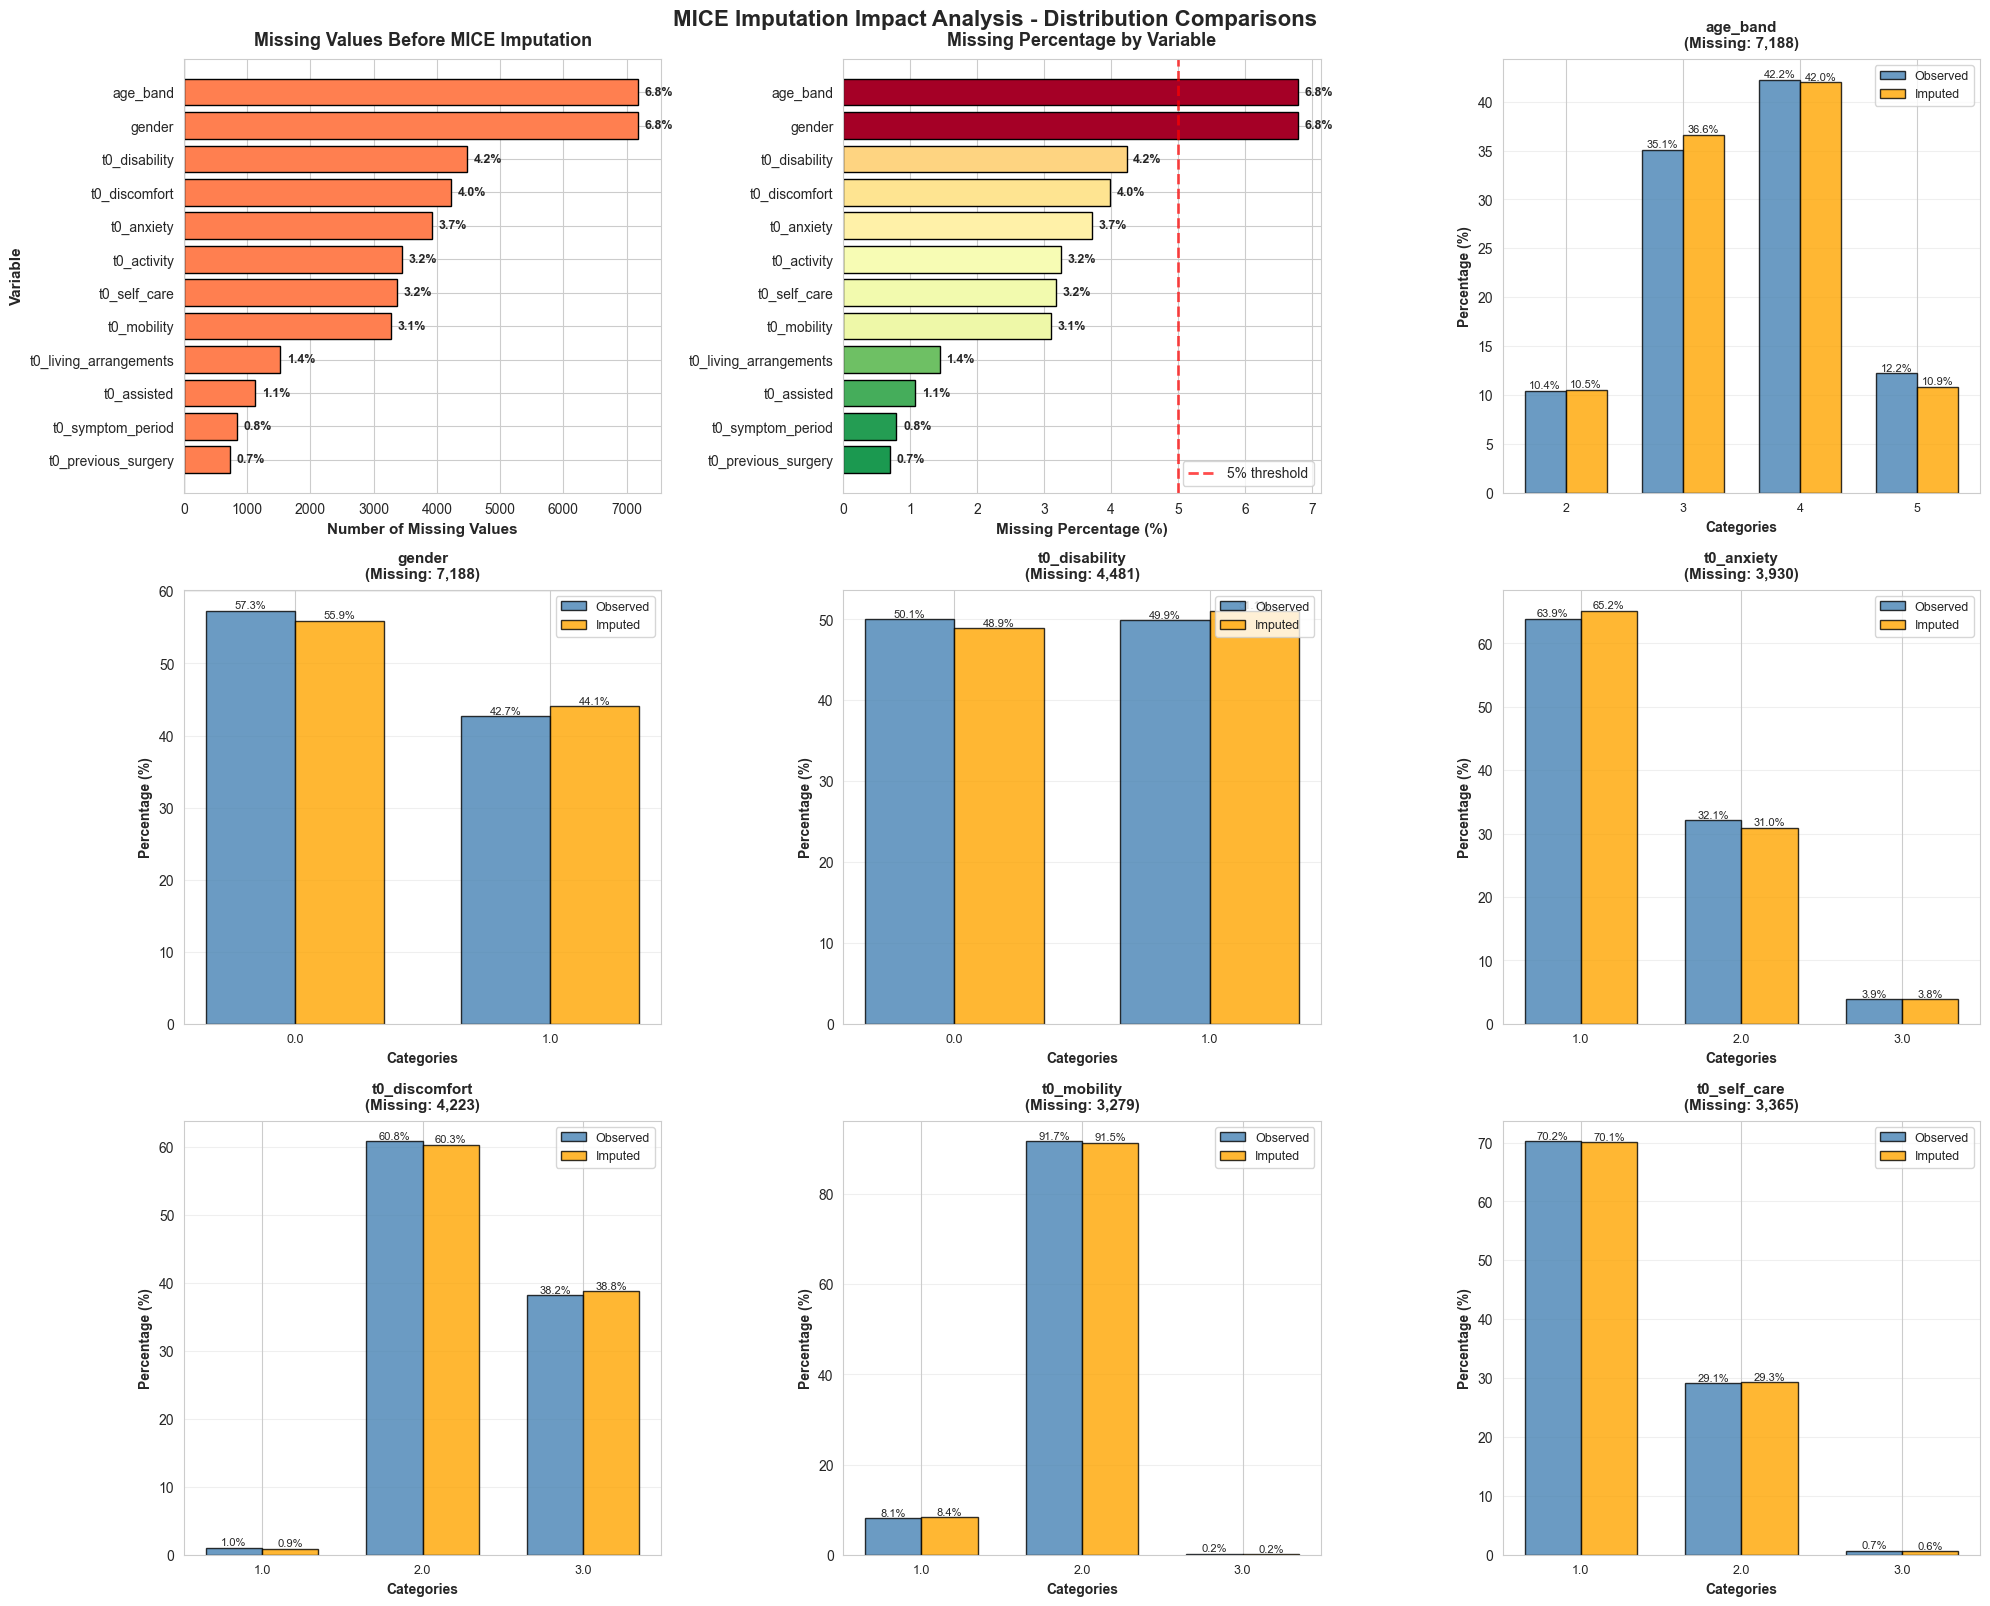

In [64]:
# ============================================================================
# VISUALIZATIONS - MICE IMPUTATION IMPACT
# ============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (20, 16)

fig = plt.figure(figsize=(20, 16))

# ============================================================================
# PLOT 1: Missing Values Summary
# ============================================================================
ax1 = plt.subplot(3, 3, 1)
missing_data = missing_summary.sort_values('Missing_Count', ascending=True)
bars = ax1.barh(missing_data['Column'], missing_data['Missing_Count'], color='coral', edgecolor='black')
ax1.set_xlabel('Number of Missing Values', fontweight='bold', fontsize=11)
ax1.set_ylabel('Variable', fontweight='bold', fontsize=11)
ax1.set_title('Missing Values Before MICE Imputation', fontsize=13, fontweight='bold', pad=10)
ax1.axvline(x=0, color='black', linewidth=0.8)

# Add percentage labels
for i, (idx, row) in enumerate(missing_data.iterrows()):
    ax1.text(row['Missing_Count'] + 100, i, f"{row['Missing_Percentage']:.1f}%", 
             va='center', fontweight='bold', fontsize=9)

# ============================================================================
# PLOT 2: Missing Value Percentages
# ============================================================================
ax2 = plt.subplot(3, 3, 2)
colors = plt.cm.RdYlGn_r(missing_data['Missing_Percentage'] / missing_data['Missing_Percentage'].max())
bars = ax2.barh(missing_data['Column'], missing_data['Missing_Percentage'], color=colors, edgecolor='black')
ax2.set_xlabel('Missing Percentage (%)', fontweight='bold', fontsize=11)
ax2.set_title('Missing Percentage by Variable', fontsize=13, fontweight='bold', pad=10)
ax2.axvline(x=5, color='red', linestyle='--', linewidth=2, alpha=0.7, label='5% threshold')
ax2.legend(loc='lower right')

# Add value labels
for i, (idx, row) in enumerate(missing_data.iterrows()):
    ax2.text(row['Missing_Percentage'] + 0.1, i, f"{row['Missing_Percentage']:.1f}%", 
             va='center', fontweight='bold', fontsize=9)

# ============================================================================
# PLOT 3-11: Distribution Comparisons for each imputed variable
# ============================================================================
plot_positions = [3, 4, 5, 6, 7, 8, 9]
plot_idx = 0

# Select variables with meaningful imputation for visualization
vars_to_plot = ['age_band', 'gender', 't0_disability', 't0_anxiety', 't0_discomfort', 
                't0_mobility', 't0_self_care']

for col in vars_to_plot:
    if col in distribution_comparison and plot_idx < len(plot_positions):
        ax = plt.subplot(3, 3, plot_positions[plot_idx])
        plot_idx += 1
        
        observed = distribution_comparison[col]['observed']
        imputed = distribution_comparison[col]['imputed']
        
        # Get value counts as percentages
        obs_pct = observed.value_counts(normalize=True).sort_index() * 100
        imp_pct = imputed.value_counts(normalize=True).sort_index() * 100
        
        # Align categories
        all_categories = sorted(set(obs_pct.index) | set(imp_pct.index))
        obs_aligned = [obs_pct.get(cat, 0) for cat in all_categories]
        imp_aligned = [imp_pct.get(cat, 0) for cat in all_categories]
        
        # Create grouped bar chart
        x = np.arange(len(all_categories))
        width = 0.35
        
        bars1 = ax.bar(x - width/2, obs_aligned, width, label='Observed', 
                       color='steelblue', alpha=0.8, edgecolor='black')
        bars2 = ax.bar(x + width/2, imp_aligned, width, label='Imputed', 
                       color='orange', alpha=0.8, edgecolor='black')
        
        ax.set_xlabel('Categories', fontweight='bold', fontsize=10)
        ax.set_ylabel('Percentage (%)', fontweight='bold', fontsize=10)
        ax.set_title(f'{col}\n(Missing: {X_train_before[col].isna().sum():,})', 
                     fontsize=11, fontweight='bold', pad=8)
        ax.set_xticks(x)
        ax.set_xticklabels(all_categories, fontsize=9)
        ax.legend(fontsize=9, loc='upper right')
        ax.grid(axis='y', alpha=0.3)
        
        # Add value labels on bars
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                if height > 0:
                    ax.text(bar.get_x() + bar.get_width()/2., height,
                           f'{height:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.suptitle('MICE Imputation Impact Analysis - Distribution Comparisons', 
             fontsize=16, fontweight='bold', y=1.001)
plt.subplots_adjust(top=0.97)
plt.show()

In [26]:
# ============================================================================
# SUMMARY REPORT - EXPORTABLE FOR DOCUMENTATION
# ============================================================================

print("\n" + "="*80)
print("MICE IMPUTATION SUMMARY REPORT")
print("="*80)
print("\nDocument Purpose: Understanding the impact of MICE imputation on NHS knee")
print("replacement surgery data for predictive modeling.")
print("\n" + "="*80)

print("\n📋 IMPUTATION METHOD")
print("-" * 80)
print("Method: MICE (Multivariate Imputation by Chained Equations)")
print("Implementation: miceforest package")
print("Iterations: 5")
print("Random State: 77 (for reproducibility)")
print("\nMICE works by:")
print("  1. Creating initial simple imputations")
print("  2. Iteratively modeling each variable with missing values based on other variables")
print("  3. Using LightGBM models to capture complex relationships")
print("  4. Repeating until convergence (5 iterations)")

print("\n📊 VARIABLES IMPUTED")
print("-" * 80)
for idx, row in missing_summary.iterrows():
    print(f"  • {row['Column']:<30} Missing: {row['Missing_Count']:>6,} ({row['Missing_Percentage']:>5.2f}%)")

total_missing = missing_summary['Missing_Count'].sum()
total_cells = len(X_train_before) * len(imputed_columns)
print(f"\n  Total cells imputed: {total_missing:,} out of {total_cells:,} ({total_missing/total_cells*100:.2f}%)")


print("\n💡 KEY FINDINGS")
print("-" * 80)

# Find variables with highest missing %
top_missing = missing_summary.head(3)
print("\nHighest Missing Value Variables:")
for idx, row in top_missing.iterrows():
    print(f"  • {row['Column']}: {row['Missing_Percentage']:.1f}% missing")


print("\n✅ CONCLUSIONS & RECOMMENDATIONS")
print("-" * 80)
print("\nStrengths:")
print(f"  ✓ MICE preserves multivariate relationships between variables")
print(f"  ✓ No missing values remain after imputation")


print("\nRecommendations for Documentation:")
print("  1. Report missing value percentages for each variable")
print("  2. Acknowledge MICE imputation method in methodology")
print("  3. Include distribution comparison plots in appendix")
print("  4. Consider sensitivity analysis with complete cases only")
print("  5. Note that imputation preserves relationships but adds uncertainty")

print("\n📁 6. DATA EXPORT")
print("-" * 80)
print("Imputed datasets saved to:")
print("  • ../data/cleaned/X_train_preprocessed.parquet")
print("  • ../data/cleaned/X_test_preprocessed.parquet")
print(f"\nTraining set: {len(X_train_imputed):,} rows × {len(X_train_imputed.columns)} columns")

print("\n" + "="*80)
print("END OF REPORT")
print("="*80)



MICE IMPUTATION SUMMARY REPORT

Document Purpose: Understanding the impact of MICE imputation on NHS knee
replacement surgery data for predictive modeling.


📋 IMPUTATION METHOD
--------------------------------------------------------------------------------
Method: MICE (Multivariate Imputation by Chained Equations)
Implementation: miceforest package
Iterations: 5
Random State: 77 (for reproducibility)

MICE works by:
  1. Creating initial simple imputations
  2. Iteratively modeling each variable with missing values based on other variables
  3. Using LightGBM models to capture complex relationships
  4. Repeating until convergence (5 iterations)

📊 VARIABLES IMPUTED
--------------------------------------------------------------------------------
  • gender                         Missing:  7,136 ( 6.86%)
  • age_band                       Missing:  7,136 ( 6.86%)
  • t0_disability                  Missing:  4,375 ( 4.21%)
  • t0_discomfort                  Missing:  4,089 ( 3.93%)


In [4]:
# Provider-level oks_delta summary: top and bottom providers
try:
    import pandas as pd
except Exception:
    import sys, subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pandas'])
    import pandas as pd
from IPython.display import display

# Ensure necessary columns exist
required_cols = {'provider_code', 'oks_delta'}
missing = required_cols - set(df.columns)
if missing:
    raise KeyError(f"Dataframe is missing required columns: {missing}")

# Compute provider-level statistics
provider_summary = (
    df.groupby('provider_code')['oks_delta']
      .agg(count='count', mean_oks_delta='mean', median_oks_delta='median', std_oks_delta='std')
      .reset_index()
)

# Sort by mean_oks_delta to identify largest and smallest increases
provider_sorted_desc = provider_summary.sort_values('mean_oks_delta', ascending=False).reset_index(drop=True)

top_providers = provider_sorted_desc.head(10).copy()
bottom_providers = provider_sorted_desc.tail(10).sort_values('mean_oks_delta', ascending=True).reset_index(drop=True)

print("Top 10 providers by mean 'oks_delta' (largest increase):")
display(top_providers)

print("\nBottom 10 providers by mean 'oks_delta' (smallest increase):")
display(bottom_providers)

# Save summaries
out_dir = '../data/cleaned'
provider_sorted_desc.to_csv(f'{out_dir}/provider_oks_delta_summary.csv', index=False)
top_providers.to_csv(f'{out_dir}/provider_oks_delta_top10.csv', index=False)
bottom_providers.to_csv(f'{out_dir}/provider_oks_delta_bottom10.csv', index=False)

print(f"Saved provider summaries to {out_dir}/provider_oks_delta_*.csv")

ModuleNotFoundError: No module named 'pandas'